In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Random data 3d
def random_data_3d(n):
    np.random.seed(42)
    x1 = np.random.uniform(140, 200, n).reshape(-1, 1)
    x2 = np.random.uniform(20, 60, n).reshape(-1, 1)
    x = np.hstack((x1, x2))
    noise = np.random.normal(0, 3, size=(n, 1))
    bias = 70 - (0.4 * 170 + 0.2 * 40)
    y = (0.4 * x1 + 0.2 * x2 + bias + noise)
    return x, y

# Random data 2d
def random_data_2d(n):
    np.random.seed(False)
    x = np.array([np.linspace(140, 200, n, dtype=np.int32)]).reshape(n, 1)
    y = (0.4 * x + np.random.randint(-5, 5, size=(n, 1))).astype(np.int32)
    return x, y

In [7]:
# Create data
x_2d, y_2d = random_data_2d(n=50)
x_3d, y_3d = random_data_3d(n=50)
print(f'x_2d: {x_2d.shape}, y_2d: {y_2d.shape}')
print(f'x_3d: {x_3d.shape}, y_3d: {y_3d.shape}')

x_2d: (50, 1), y_2d: (50, 1)
x_3d: (50, 2), y_3d: (50, 1)


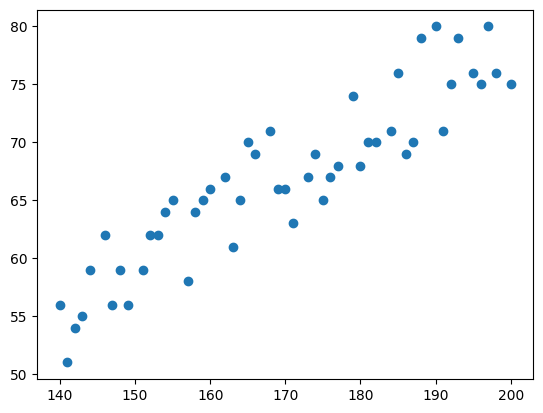

In [8]:
# Visualize data 2d
plt.scatter(x_2d, y_2d)
plt.show()

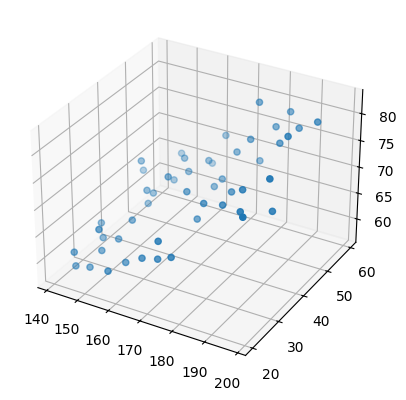

In [9]:
# Visualize data 3d
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_3d[:, 0], x_3d[:, 1], y_3d.flatten())
plt.show()

In [10]:
# Linear regression
class LinearRegression:
    def __init__(self):
        self.w = None
        self.b = None

    def fit(self, X, y):
        # add bias column
        #X = np.hstack([np.ones((X.shape[0], 1)), X]) #noi theo truc 1 (cot)
        #np.vstack() noi theo truc 0 (hang)

        ones = np.ones((X.shape[0], 1))
        X = np.concatenate((ones, X), axis=1)

        theta = np.linalg.pinv(X.T @ X) @ X.T @ y

        self.b = theta[0]
        self.w = theta[1:]

    def predict(self, x):
        return x @ self.w + self.b

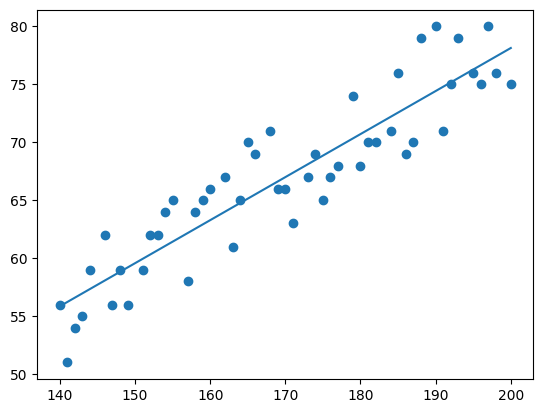

In [11]:
# Model
model_1 = LinearRegression()
model_1.fit(x_2d, y_2d)
y_2d_pred = model_1.predict(x_2d)

# Visualize
plt.scatter(x_2d, y_2d)
plt.plot(x_2d, y_2d_pred)
plt.show()

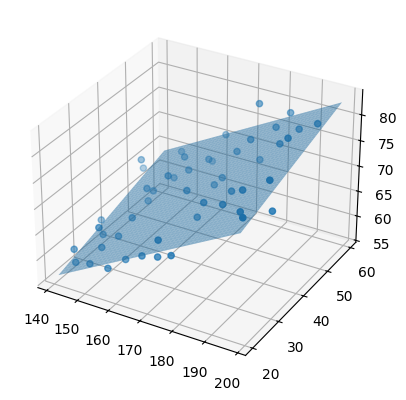

In [8]:
# Model
model_2 = LinearRegression()
model_2.fit(x_3d, y_3d)
y_3d_pred = model_2.predict(x_3d)

# Visualize
fig = plt.figure()

ax = fig.add_subplot(111, projection='3d')
ax.scatter(x_3d[:, 0], x_3d[:, 1], y_3d.flatten())
x1_range = np.linspace(x_3d[:, 0].min(), x_3d[:, 0].max(), 50)
x2_range = np.linspace(x_3d[:, 1].min(), x_3d[:, 1].max(), 50)
x1_grid, x2_grid = np.meshgrid(x1_range, x2_range)
z = model_2.w[0] * x1_grid + model_2.w[1] * x2_grid + model_2.b
ax.plot_surface(x1_grid, x2_grid, z, alpha=0.5)

plt.show()